In [89]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import kagglehub
from kagglehub import KaggleDatasetAdapter

In [90]:
file_path = "Wholesale customers data.csv"
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "binovi/wholesale-customers-data-set",
    file_path,
)

print("Первые 5 строк:")
print(df.head())

/tmp/ipykernel_713/3453790722.py:2: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'wholesale-customers-data-set' dataset.
Первые 5 строк:
   Channel  Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen
0        2       3  12669  9656     7561     214              2674        1338
1        2       3   7057  9810     9568    1762              3293        1776
2        2       3   6353  8808     7684    2405              3516        7844
3        1       3  13265  1196     4221    6404               507        1788
4        2       3  22615  5410     7198    3915              1777        5185


In [91]:
df = pd.get_dummies(df, columns=['Channel', 'Region'])

In [92]:
scaler = StandardScaler()
X = scaler.fit_transform(df)

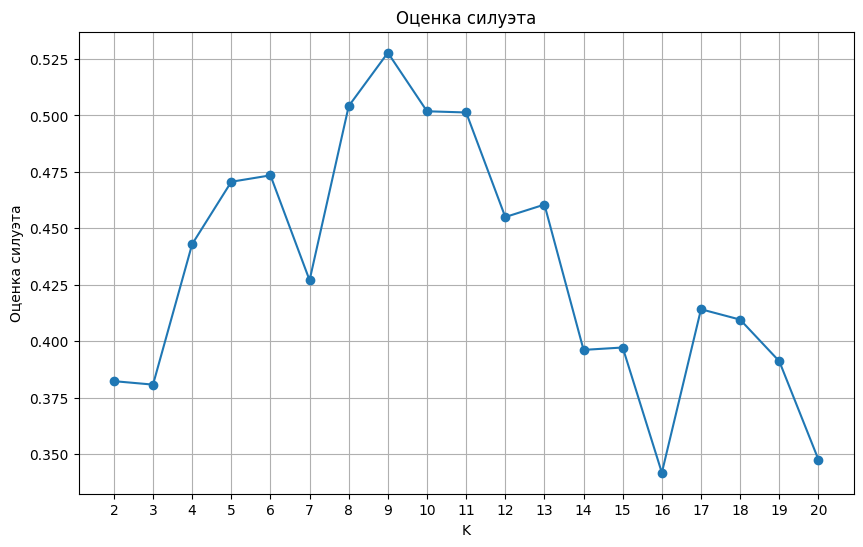

In [93]:
silhouette_scores = []
K_range = range(2, 21)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(K_range, silhouette_scores, marker='o')
plt.title('Оценка силуэта')
plt.xlabel('K')
plt.ylabel('Оценка силуэта')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [94]:
kmeans = KMeans(n_clusters=9, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X)

print(f"Silhouette Score: {silhouette_score(X, kmeans_labels):.4f}")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for i, count in zip(unique, counts):
    print(f"Кластер {i}: {count} объектов")

Silhouette Score: 0.5278
Кластер 0: 97 объектов
Кластер 1: 198 объектов
Кластер 2: 11 объектов
Кластер 3: 58 объектов
Кластер 4: 1 объектов
Кластер 5: 14 объектов
Кластер 6: 18 объектов
Кластер 7: 27 объектов
Кластер 8: 16 объектов


In [95]:
pca = PCA(n_components=5)
X_pca = pca.fit_transform(X)

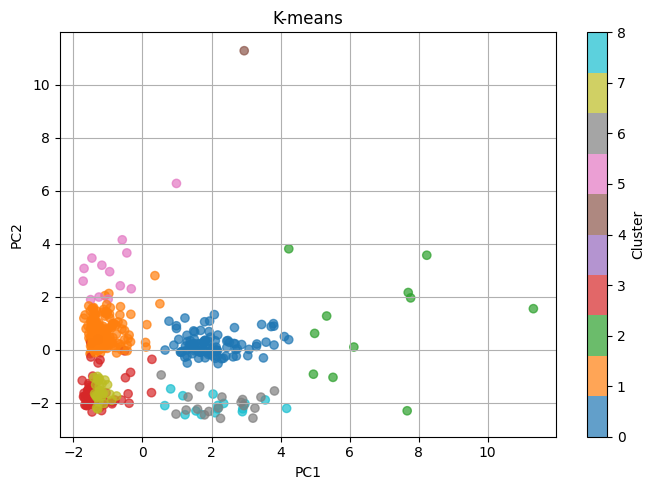

In [96]:
plt.figure(figsize=(7, 5))
scatter1 = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.7)
plt.title(f'K-means')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.colorbar(scatter1, label='Cluster')
plt.tight_layout()
plt.show()

In [97]:
dbscan = DBSCAN(eps=2.5, min_samples=10)
dbscan_labels = dbscan.fit_predict(X)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Кластеров: {n_clusters}")
print(f"Шумовых точек: {n_noise}")

Кластеров: 6
Шумовых точек: 14


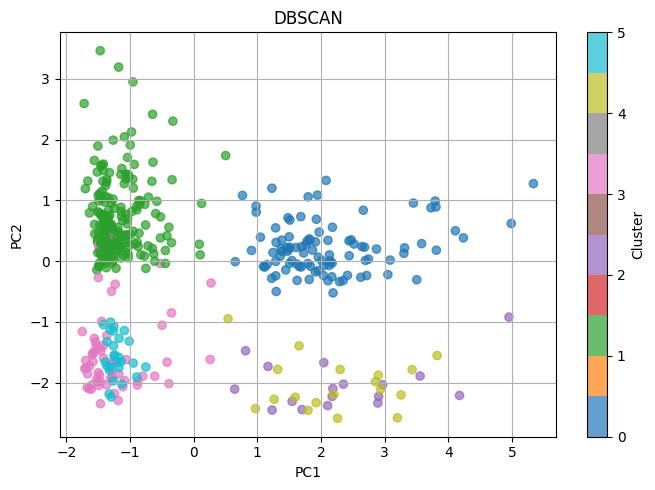

In [98]:
plt.figure(figsize=(7, 5))
dbscan_filtered_indices = dbscan_labels != -1
scatter2 = plt.scatter(X_pca[dbscan_filtered_indices, 0], X_pca[dbscan_filtered_indices, 1],
                          c=dbscan_labels[dbscan_filtered_indices], cmap='tab10', alpha=0.7)
plt.title(f'DBSCAN')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.grid(True)
plt.colorbar(scatter2, label='Cluster')
plt.tight_layout()
plt.show()

In [99]:
df_kmeans = df.copy()
df_kmeans['KMeans_Cluster'] = kmeans_labels

cluster_means = df_kmeans.groupby('KMeans_Cluster').mean()
display(cluster_means)

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Channel_1,Channel_2,Region_1,Region_2,Region_3
KMeans_Cluster,,,,,,,,,,,
0,9001.072165,8514.814433,13488.041237,1389.680412,5643.680412,1598.010309,0.0,1.0,0.000000,0.000000,1.000000
1,11538.777778,3028.565657,3574.308081,2873.575758,770.939394,1167.550505,1.0,0.0,0.000000,0.000000,1.000000
2,16911.090909,34864.363636,46126.181818,3245.454545,23008.090909,4177.363636,0.0,1.0,0.181818,0.090909,0.727273
3,12596.706897,3812.637931,4011.120690,2858.637931,953.758621,1168.206897,1.0,0.0,1.000000,0.000000,0.000000
4,36847.000000,43950.000000,20170.000000,36534.000000,239.000000,47943.000000,1.0,0.0,0.000000,0.000000,1.000000
5,47863.214286,8295.714286,7910.071429,17548.857143,1081.428571,3551.785714,1.0,0.0,0.071429,0.071429,0.857143
6,7218.944444,9424.722222,13494.555556,1618.888889,6760.722222,1240.333333,0.0,1.0,0.000000,1.000000,0.000000
7,10870.296296,1767.962963,4053.629630,3703.407407,453.481481,939.111111,1.0,0.0,0.000000,1.000000,0.000000
8,4709.187500,8915.812500,16200.937500,2189.500000,6878.187500,1606.500000,0.0,1.0,1.000000,0.000000,0.000000
